# Absorption and Diffusion

This part is meant to combine all our previous results for absorption, diffusion, and convection shown in the previous three notebooks. The goal is to solve for:

\begin{equation}
\left\{\begin{aligned}
    \partial_t\rho_g&= D(\Delta\rho_g)-\mathbf{v}\cdot(\nabla\rho_g) \\
    \partial_t\rho_s&= 0
\end{aligned}\right.
\end{equation}
Where $\rho_g$ is the density at that point and $\rho_s$ is the saturation of the metal. $D$ is the diffusivity, and $\mathbf{v}$ the velocity ($\mathbf v=(v_x, v_y)$).

Under initial condition and boundary conditions are (since there is no coupling effects of saturation of the metal I am pretty sure we do not need boundary conditions there, but I'll look into this and phrase it more rigorous):

\begin{equation}
\left\{ \begin{aligned}
    \rho_g(\mathbf{x}, 0)  &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_s(\mathbf{x},0) &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_g(\mathbf{x}, t)  &= 1, &\forall \mathbf{x}\in\partial\Omega_1,\forall t\geq 0, \\
    \partial_\mathbf{n}\rho_g(\mathbf{x}, t)  &= 0, &\forall \mathbf{x}\in\partial\Omega_2,\forall t\geq 0. \\

\end{aligned}\right.
\end{equation}

where $\mathbf x = (x, y)$. Since the saturation equation contains no spatial derivatives, $\rho_s$ is governed by a local ordinary differential equation and therefore only requires an initial condition, not a boundary condition.

We will be expanding $\hat\rho_g$, and $\hat\rho_s$ into Lagrange polynomials. In our case now we do not yet discretize into time since the solver will do that for us. Previously we would be working with $\rho_g^n$, as indication of time steps, now $\hat{}$ will indicate the last step before time discretization (so the final semi-discrete formulation):

\begin{equation*}
\begin{aligned}
\hat\rho_g(x, t)&=\sum{\hat \rho_g^{i}(t)\psi^i(x)},\\
\hat\rho_s(x, t)&=\sum{\hat \rho_s^{i}(t)\psi^i(x)}.
\end{aligned}
\end{equation*}

we want to solve for $\hat \rho_g$ and $\hat \rho_s$, so our solution vector $\hat {\mathbf{u}}$ becomes:

$$
\hat{\mathbf{u}} = \begin{pmatrix}\hat\rho_g^{1} \\ \vdots \\ \hat\rho_g^{N} \\ \hat\rho_s^{1} \\ \vdots \\ \hat\rho_s^{N}
\end{pmatrix}
$$

Our last semi-discrete step becomes now:

$$
\begin{aligned}
M(\partial_t \hat {\mathbf{u}}) = -(K+C)\hat{\mathbf{u}}\\
M(\partial_t \hat {\mathbf{u}}) = A\hat{\mathbf{u}} = f(\hat{\mathbf{u}}, t)& \qquad \text{where }A=-(K+C)\text{ and }f= A\hat{\mathbf{u}}
\end{aligned}
$$

where (we initially have both $\rho_g$ and $\rho_s$ be the same Lagrange polynomial degree):

\begin{equation*}
\begin{aligned}
K &= \begin{pmatrix}
        K^{gg} & 0 \\ 
        0      & 0
    \end{pmatrix}\\
K^{gg}&=D\int(\nabla \psi^i)(\nabla\psi^j)dx \\
C &= \begin{pmatrix}
        C^{gg} & 0 \\ 
        0      & 0
    \end{pmatrix}\\
C^{gg}_{ij}&=\mathbf{v}\cdot\int(\nabla\psi^i)\psi^jdx
\end{aligned}
\end{equation*}

and also the Jacobian:

\begin{equation*}
J f = A
\end{equation*}

## Import Julia Packages 

In [3]:
using Ferrite, SparseArrays, BlockArrays, LinearAlgebra, LinearSolve, DiffEqBase, DifferentialEquations
# WriteVTK
# Plots
# Sundials for CVODE
# BenchmarkTools


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


In [2]:
using Ferrite
using OrdinaryDiffEq
using LinearSolve
using SparseArrays
using LinearAlgebra
using BenchmarkTools

## FEM definitions/Ferrite calls

In [1]:
name = "abs_conv_diff_jac_2";

# Stop time, time step
dt = .01;
T = 10.0;

k = 1.0;         # rate of absorption
rho_sat = 1.0;   # saturation density of metal

vx = 1.0;        # x-velocity for convection
vy = 0.0;        # y-velocity for convection
velocity = Vec((vx, vy));
                 # ↑ total velocity 

D = 1.0;         # Diffusivity for diffusion

LoadError: UndefVarError: `Vec` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [4]:
# generates 20 gridpoints between 
grid = generate_grid(Quadrilateral, (100, 100), Vec((0.0, 0.0)), Vec((1.0, 1.0)));

# generate the same 
qr = QuadratureRule{RefQuadrilateral}(2);

ip_rho = Lagrange{RefQuadrilateral, 1}();
cellvalues_rho = CellValues(qr, ip_rho);

ip_rhos = Lagrange{RefQuadrilateral, 1}()
cellvalues_rhos = CellValues(qr, ip_rhos);

# degree of freedom handler, 
dh = DofHandler(grid)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rhos)
close!(dh);

In [5]:
N = ndofs(dh)

20402

In [6]:
# for now we have no constraints
ch = ConstraintHandler(dh)

#create left_slit
addfacetset!(
    grid,
    "left_slit",
    x -> abs(x[1]) < 1e-8 && 0.25 <= x[2] <= 0.75
)

dbc_left = Dirichlet(
    :rho,
    getfacetset(grid, "left_slit"),
    (x, t) -> 1.0
)

add!(ch, dbc_left)
close!(ch)
update!(ch, 0.0)

## M, K, C, and A matrices definitions and allocations

In [7]:
function doassemble_M!(M, cellvalues_rho, cellvalues_rhos, dh)
    assembler = start_assemble(M)

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rhos = getnbasefunctions(cellvalues_rhos)

    # loop over all cells
    for cell in CellIterator(dh)
        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Me = zeros(ndofs_cell, ndofs_cell)

        # rho
        Ferrite.reinit!(cellvalues_rho, cell)
        for q in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q, j)
                    # :rho DOFs are first in cell_dofs
                    Me[i, j] += psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rhos, cell)
        for q in 1:getnquadpoints(cellvalues_rhos)
            dx = getdetJdV(cellvalues_rhos, q)
            for i in 1:n_basefuncs_rhos
                psi_i = shape_value(cellvalues_rhos, q, i)
                for j in 1:n_basefuncs_rhos
                    psi_j = shape_value(cellvalues_rhos, q, j)
                    # :rho_s DOFs are after :rho in cell_dofs
                    offset = n_basefuncs_rho
                    Me[offset + i, offset + j] += psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end

    return M
end

doassemble_M! (generic function with 1 method)

In [8]:
function doassemble_K!(
    K::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rhos::CellValues, 
    dh::DofHandler
    )

    assembler = start_assemble(K)

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rhos = getnbasefunctions(cellvalues_rhos)

    for cell in CellIterator(dh)

        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Ke = zeros(ndofs_cell, ndofs_cell)

        # rho is the only important bit since rho_s does not diffuse
        Ferrite.reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)
                    # D∫ (∇ψ^i) ⋅ (∇ψ^j)dx
                    Ke[i, j] += D * (dpsi_j ⋅ dpsi_i) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Ke)
    end

    return K
end


doassemble_K! (generic function with 1 method)

In [9]:
function doassemble_C!(
    K::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rhos::CellValues, 
    dh::DofHandler
    )

    n_basefuncs_rho = getnbasefunctions(cellvalues_rho)
    Ce = zeros(n_basefuncs_rho, n_basefuncs_rho)

    assembler = start_assemble(C)

    for cell in CellIterator(dh)
        
        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Ce = zeros(ndofs_cell, ndofs_cell)

        # rho is the only important bit since rho_s does not diffuse
        Ferrite.reinit!(cellvalues_rho, cell)
        fill!(Ce, 0)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)
                    # -v \psi^i(\partial_x\psi^j)dx
                    Ce[i, j] += (velocity ⋅ dpsi_j) *  psi_i * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Ce)
    end

    return C
end


doassemble_C! (generic function with 1 method)

In [10]:
M = allocate_matrix(dh);
K = allocate_matrix(dh);
C = allocate_matrix(dh);

M = doassemble_M!(M, cellvalues_rho, cellvalues_rhos, dh);
K = doassemble_K!(K, cellvalues_rho, cellvalues_rhos, dh);
C = doassemble_C!(C, cellvalues_rho, cellvalues_rhos, dh);

A = -(K+C)

20402×20402 SparseMatrixCSC{Float64, Int64} with 90601 stored entries:
⎡⠿⣧⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⎦

## ODE Definitions

In [11]:
ndofs_total = ndofs(dh)
u_n = zeros(ndofs_total)
u_0 = zeros(ndofs_total)

apply!(u_n, ch)
apply!(M, ch);

u_0 .= u_n

jac_sparsity = sparse(A);

In [12]:
struct RHSparams
    A::SparseMatrixCSC
    ch::ConstraintHandler
    dh::DofHandler
    cellvalues_rho::CellValues
    cellvalues_rhos::CellValues
    u::Vector
end

In [13]:
p = RHSparams(A, ch, dh, cellvalues_rho, cellvalues_rhos, copy(u_n));

In [14]:
function f!(
    du,
    u_c,
    p :: RHSparams,
    t
)
    (; A, ch, dh, cellvalues_rho, cellvalues_rhos, u) = p;
    
    # we cannot alter u_c, so we allocate a new u 
    # if I understand the tutorial correctly we can increase computation by pre-allocating this variable
    u .= u_c;

    # update time-dependent constraint handler 
    # currently ch is dirichlet without a time aspect, so it does nothing
    # I feel like we have this twice (also in the limiter), so maybe one can go?
    update!(ch, t);

    # below will be done in limiter
    # apply!(u, ch);

    # using mul is an inbuilt function that will work better than normal .* -arithmetics
    # also better allocation wise?
    mul!(du, A, u) # du .= A * u

    # below will be the non-linear contributions
    # ...

    return
end

f! (generic function with 1 method)

In [15]:
function Jf!(
    J,
    u_c,
    p :: RHSparams,
    t
)
    # unpack parameters
    (; A, ch, dh, cellvalues_rho, cellvalues_rhos, u) = p;

    # again same as rhs() function
    u .= u_c
    update!(ch, t)
    apply!(u, ch)    

    # Linear contribution (Stokes operator)
    # Here we assume that J has exactly the same structure as K by construction
    copyto!(J, A)    

    # below the non-linear contributions
    # ...

    # And apply bc
    apply!(J, ch)
    
    return 
end

Jf! (generic function with 1 method)

In [16]:
rhs = ODEFunction(
    f!, 
    mass_matrix = M; 
    jac = Jf!, 
    jac_prototype = jac_sparsity
)
problem = ODEProblem(rhs, u_0, (0.0, T), p);

In [17]:
# Wordt na elke tijdstap uitgevoerd om de bc up te daten en drift te corrigeren
function ferrite_limiter!(u, integrator, p, t)
    update!(p.ch, t)
    apply!(u, p.ch)
    return 
end;

In [ ]:
struct FreeDofErrorNorm
    ch::ConstraintHandler
end
(fe_norm::FreeDofErrorNorm)(u::Union{AbstractFloat, Complex}, t) = DiffEqBase.ODE_DEFAULT_NORM(u, t)
(fe_norm::FreeDofErrorNorm)(u::AbstractArray, t) = DiffEqBase.ODE_DEFAULT_NORM(u[fe_norm.ch.free_dofs], t)

timestepper = Rodas5P(
    autodiff = false, 
    step_limiter! = ferrite_limiter!
);
timestepper2 = Rodas5P(
    autodiff = false,
    step_limiter! = ferrite_limiter!,
    linsolve = KrylovJL_GMRES()
);

sol = solve(problem, timestepper, 
# saveat=0:0.01:T
; abstol = 1.0e-2, reltol = 1.0e-3);
# sol2 = solve(problem, timestepper2, saveat=0:0.01:T; abstol = 1.0e-3, reltol = 1.0e-4);

In [44]:
sol.t

429-element Vector{Float64}:
 0.0
 1.0e-6
 3.7555822138745775e-6
 9.534176272661214e-6
 1.9589006962970854e-5
 3.5111986635326725e-5
 5.785454987875368e-5
 9.419149972785688e-5
 0.00013740081705617975
 0.0001909905122124779
 ⋮
 0.0979493664193271
 0.09820592875324041
 0.09846254307125066
 0.09871920923316603
 0.09897592719266012
 0.09923269680940106
 0.09948951803696035
 0.09974639073486656
 0.1

## plotting/testing

In [45]:
using Plots

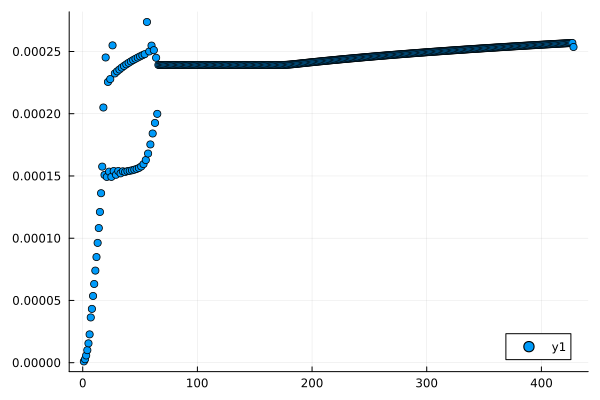

In [47]:
scatter(sol.t[2:end]-sol.t[1:end-1])

In [48]:
# To distinguish degrees of freedom from variables. 
# Feel like there must be a quicker way but can't find it...
rho_dofs = Int[] 
rhos_dofs = Int[] 

for cell in CellIterator(dh) 
    cdofs = celldofs(cell) 
    append!(rho_dofs, cdofs[dof_range(dh, :rho)]) 
    append!(rhos_dofs, cdofs[dof_range(dh, :rho_s)]) 
end 

rho_dofs = unique(rho_dofs); 
rhos_dofs = unique(rhos_dofs);

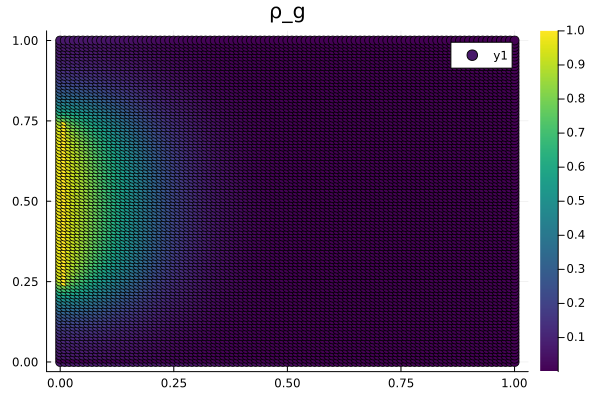

In [49]:
u = sol.u[end]

rho = u[rho_dofs]

coords = [get_node_coordinate(node) for node in grid.nodes]
x = [c[1] for c in coords]
y = [c[2] for c in coords]

scatter(x, y,
    marker_z = rho,
    color = :viridis,
    ms = 5,
    colorbar = true,
    title = "ρ_g")

In [68]:
Pkg.add("GLMakie")

   Resolving package versions...
   Installed GLFW ───── v3.4.6
   Installed ModernGL ─ v1.1.8
   Installed GLMakie ── v0.13.9
   Installed MeshIO ─── v0.5.3
    Updating `C:\Users\noudh\.julia\environments\v1.12\Project.toml`
  [e9467ef8] + GLMakie v0.13.9
    Updating `C:\Users\noudh\.julia\environments\v1.12\Manifest.toml`
  [f7f18e0c] + GLFW v3.4.6
  [e9467ef8] + GLMakie v0.13.9
  [7269a6da] + MeshIO v0.5.3
  [66fc600b] + ModernGL v1.1.8
Precompiling packages...
  22097.8 ms  ✓ ModernGL
  26484.8 ms  ✓ MeshIO
   3410.0 ms  ✓ GLFW
  11364.4 ms  ? StochasticDiffEq
  16850.9 ms  ? DifferentialEquations
 181654.2 ms  ✓ GLMakie
  4 dependencies successfully precompiled in 261 seconds. 646 already precompiled.
  2 dependencies precompiled but different versions are currently loaded. Restart julia to access the new versions. Otherwise, loading dependents of these packages may trigger further precompilation to work with the unexpected versions.
  2 dependencies failed but may be precompila

In [69]:
using Makie, GLMakie

Makie.scatter(x, y, color=rho)

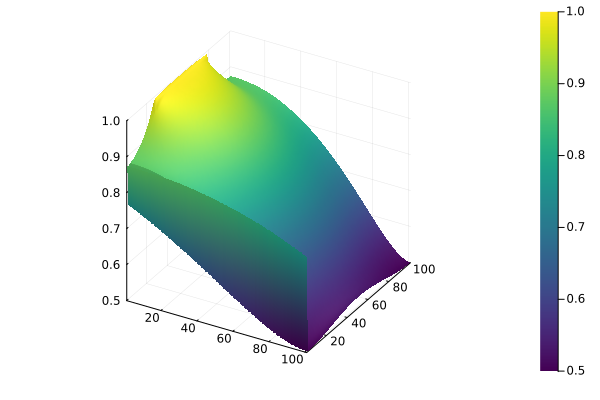

In [60]:
nx, ny = 101, 101  # nodes = elements + 1

rho_grid = reshape(rho, nx, ny)

# heatmap(rho_grid', color = :viridis)
surface(rho_grid', color = :viridis)

## Saving as PTK

In [46]:
using WriteVTK

In [47]:
pvd = paraview_collection(joinpath(name, name))
for (step, (u, t)) in enumerate(zip(sol.u, sol.t))
    VTKGridFile(joinpath(name, "$(name)-$step"), dh) do vtk
        write_solution(vtk, dh, u)
        pvd[t] = vtk
    end
end
vtk_save(pvd);

# Benchmarking

In [ ]:
using BenchmarkTools

In [ ]:
# test vectors
u_test  = copy(u_0)
du_test = similar(u_0)

# Jacobian matrix (same sparsity as A)
J_test = copy(jac_sparsity)

# time
t_test = 0.5

0.5

In [2]:
u_test

UndefVarError: UndefVarError: `u_test` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [35]:
@btime f!($du_test, $u_test, $p, $t_test)

  99.600 μs (14 allocations: 624 bytes)


In [32]:
@benchmark f!($du_test, $u_test, $p, $t_test)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):   99.900 μs …  4.339 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     102.200 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   108.779 μs ± 51.521 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █▇▄▃▃▃▂▂▂▁▁▁                                                 ▁
  ██████████████▇█▇█▇▇▆▆▇▇▆▅▆▅▆▆▅▆▅▅▃▅▅▅▄▅▄▅▄▅▂▅▅▄▄▅▃▄▄▄▃▄▃▅▂▃ █
  99.9 μs       Histogram: log(frequency) by time       209 μs <

 Memory estimate: 624 bytes, allocs estimate: 14.

In [33]:
@benchmark Jf!($J_test, $u_test, $p, $t_test)

BenchmarkTools.Trial: 6590 samples with 1 evaluation per sample.
 Range (min … max):  630.700 μs …  12.028 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     670.150 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   753.442 μs ± 235.821 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▇█▆▅▄▄▃▃▃▃▃▃▃▃▃▂▂▂▁▁▁▁▁                                       ▂
  █████████████████████████████▇▇▆▇▇▇▇▆▇▆▆▇▆▅▅▆▆▅▄▅▅▃▅▅▄▅▃▄▄▃▄▆ █
  631 μs        Histogram: log(frequency) by time       1.55 ms <

 Memory estimate: 752 bytes, allocs estimate: 17.

In [34]:
@benchmark ferrite_limiter!($u_test, nothing, $p, $t_test)

BenchmarkTools.Trial: 10000 samples with 6 evaluations per sample.
 Range (min … max):  5.333 μs … 30.150 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     5.567 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   5.744 μs ±  1.057 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▆██▅▃▂▁            ▁▁                                      ▂
  ██████████▇▆▆▆▅▄▃▆███▇▅▅▄▃▅▅▄▄▃▅▄▄▅▄▁▃▁▄▄▄▁▄▃▃▅▄▃▃▄▄▄▄▄▃▃▃ █
  5.33 μs      Histogram: log(frequency) by time     11.9 μs <

 Memory estimate: 592 bytes, allocs estimate: 13.

In [20]:
@btime solve(
    problem, 
    timestepper;
    save_on = false, 
    # verbose = true,  
    abstol = 1.0e-4, 
    reltol = 1.0e-5
)

  128.290 s (242409 allocations: 29.87 GiB)


retcode: Success
Interpolation: specialized 4th (Rodas6P = 5th) order "free" stiffness-aware interpolation
t: 2-element Vector{Float64}:
 0.0
 0.1
u: 2-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.06336532404415222, 0.06328196602661507, 0.06410488238387087, 0.06418963065510444, 0.0, 0.0, 0.0, 0.0, 0.06302513731646754, 0.06384377971093003  …  7.347509828862767e-11, 0.0, 4.756358910034524e-11, 0.0, 3.1844762318328774e-11, 0.0, 2.3354328780936628e-11, 0.0, 2.0650384331017153e-11, 0.0]

In [39]:
sol.t

11-element Vector{Float64}:
 0.0
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 0.1

In [42]:
sol.destats

SciMLBase.DEStats
Number of function 1 evaluations:                  5186
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    576
Number of linear solves:                           4608
Number of Jacobians created:                       576
Number of nonlinear solver iterations:             0
Number of nonlinear solver convergence failures:   0
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          576
Number of rejected steps:                          0

In [25]:
sol.destats

SciMLBase.DEStats
Number of function 1 evaluations:                  5186
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    576
Number of linear solves:                           4608
Number of Jacobians created:                       576
Number of nonlinear solver iterations:             0
Number of nonlinear solver convergence failures:   0
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          576
Number of rejected steps:                          0

In [16]:
sol.t

UndefVarError: UndefVarError: `sol` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [26]:
sol2.destats

SciMLBase.DEStats
Number of function 1 evaluations:                  24176
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    100
Number of linear solves:                           800
Number of Jacobians created:                       0
Number of nonlinear solver iterations:             0
Number of nonlinear solver convergence failures:   0
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          100
Number of rejected steps:                          0

# Not working below

In [29]:
sol2 = solve(
    problem, 
    CVODE_BDF(linear_solver = :GMRES);
    save_on = false, 
    # verbose = true,  
    abstol = 1.0e-4, 
    reltol = 1.0e-5
)

ErrorException: This solver is not able to use mass matrices.

In [22]:
@btime solve(
    problem, 
    CVODE_BDF(linear_solver = :GMRES);
    save_on = false, 
    # verbose = true,  
    abstol = 1.0e-4, 
    reltol = 1.0e-5
)

UndefVarError: UndefVarError: `CVODE_BDF` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name also exists in Sundials.

In [10]:
# I use this later to distinguish between degrees of freedom for 
rho_dofs  = Int[]
rhos_dofs = Int[]

for cell in CellIterator(dh)
    cdofs = celldofs(cell)

    append!(rho_dofs,  cdofs[dof_range(dh, :rho)])
    append!(rhos_dofs, cdofs[dof_range(dh, :rho_s)])
end

rho_dofs  = unique(rho_dofs);
rhos_dofs = unique(rhos_dofs);

In [ ]:
# I keep the below because it also creates the rhs cdotm,
# so it will be of use laterz

mdot = zeros(ndofs_total)
A_fact = lu(A)

# finally the timeloop
for (step, t) in enumerate(dt:dt:T)
    
    #First of all, we need to update the Dirichlet boundary condition values.
    update!(ch, t)


    # now we reset ̇m. I think both do the same, so maybe not necessary haha
    mdot = zeros(ndofs_total)
    mdot .= 0.0

    # important: because of our assumptions above, we iterate over degrees of freedom/nodes, not cells
    # the cell relavance will be added after M*mdot
    for (i_rho, i_rhos) in zip(rho_dofs, rhos_dofs)

        # for now: mdto = kρ(ρsat-ρs)
        md = k * u_n[i_rho] * (rho_sat - u_n[i_rhos])

        mdot[i_rhos] += md
        mdot[i_rho]  -= md
    end

    # b without boundary elements
    b = M * u_n  + dt * (M * mdot)

    #Then, we can apply the boundary conditions of the current time step.
    apply_rhs!(rhsdata, b, ch)

    #Finally, we can solve the time step and save the solution afterwards.
    u = A_fact \ b

    
    VTKGridFile(joinpath(name, "$(name)-$step"), dh) do vtk
        write_solution(vtk, dh, u)
        pvd[t] = vtk
    end
    #At the end of the time loop, we set the previous solution to the current one and go to the next time step.
    u_n .= u
    # keep this for plotting
    rho_hist[step] = u_n[1]
    rhos_hist[step] = u_n[5]

end
    
    # # Secondly, we compute the right-hand-side of the problem.
    # # OLD But maybe usefull later if we do error analysis. iterates per cell instead of per node
    # # Currently hardcoded 1/1600 and no integration (which should happen like in the construction of our matrices M, K, and C)
    # for cell in CellIterator(dh)
    #     cell_dofs = celldofs(cell)
    #     n_rho   = getnbasefunctions(cellvalues_rho)
    #     n_rhos  = getnbasefunctions(cellvalues_rhos)
    #     dofs_rho  = cell_dofs[1:n_rho]
    #     dofs_rhos = cell_dofs[n_rho+1:end]

    #     # local values
    #     rho_vals   = x_n[dofs_rho]
    #     rho_s_vals = x_n[dofs_rhos]

    #     # compute the absorption term drho_sdt per DOF
    #     for (i_rho, i_rhos) in zip(dofs_rho, dofs_rhos)
    #         # mdot
    #         dms = drho_sdt(x_n[i_rhos], x_n[i_rho], t)

    #         # add to CHANGE vector
    #         mdot[i_rhos] += 1.0/1600.0 #dms
    #         # gas is consumed, optional:
    #         mdot[i_rho]  -= 1.0/1600.0 #dms
    #     end
    # end

In [ ]:
vtk_save(pvd);